# 03 — SHAP Attribution for the XGBoost Ranker

**Why this notebook exists.** Notebook 02 showed `xgb_ranker` wins on IC-IR
(0.20 vs 0.11 for the handmade `naive_ew`). That headline leaves two things
unclear:

1. Is the XGB ranker just re-learning the three hand-picked features
   (`size_adv_60`, `vol_60d`, `reversal_1w`) with more noise, or is it
   genuinely leaning on the other nine features — in particular the
   "wrong-sign momentum" group (`rsi_14`, `ret_21d`, `macd_hist`, `ret_63d`)
   that `01_feature_eda` flagged as useful only *after* a sign flip the
   linear baselines can't perform?
2. Does the dependence shape tell us anything about the mechanism? For
   example, if SHAP(`size_adv_60`) is monotone decreasing, that's just a
   size tilt; if it's U-shaped, it's a conditional effect the tree picked
   up and a linear model would miss.

**Scope.** One XGB model, trained on 2015-01-01 → 2023-12-31 (matches W6's
final fold). SHAP computed on a stratified sample from the 2024 OOS year,
~10k rows. Per-fold time-drift SHAP is *deferred* to SDD — it's an
interesting follow-up but out of scope for the MVP narrative.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from mlcs.model import XGBRankerModel

PROC_DIR = Path("../data/processed")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 110

In [2]:
candidates = sorted(PROC_DIR.glob("features_*.parquet"))
df = pd.read_parquet(candidates[-1])
df["date"] = pd.to_datetime(df["date"])

FEATURES = [
    "mom_12_1", "reversal_1w", "size_adv_60",
    "ret_21d", "ret_63d", "ret_126d", "ret_252d",
    "vol_20d", "vol_60d",
    "rsi_14", "macd_hist", "volume_z_60",
]
TARGET = "fwd_rank_21d"

train = df[df["date"] < "2024-01-01"].dropna(subset=[TARGET])
test  = df[(df["date"] >= "2024-01-01") & (df["date"] < "2025-01-01")].dropna(subset=FEATURES + [TARGET])
print(f"train rows: {len(train):,}   test rows: {len(test):,}")

train rows: 1,093,230   test rows: 125,417


## 1. Re-train the XGB model used by W6's 2024 fold

In [3]:
import time

mdl = XGBRankerModel(n_estimators=400, max_depth=5, learning_rate=0.05, random_state=42)
t0 = time.time()
mdl.fit(train[FEATURES], train[TARGET], train["date"])
print(f"fit in {time.time() - t0:.1f}s")

# sanity check: reproduce the OOS IC number from notebook 02
scores = mdl.predict(test[FEATURES], test["date"])
ic_check = test[["date"]].copy()
ic_check["score"] = scores
ic_check["target"] = test[TARGET].values
per_date_ic = ic_check.groupby("date").apply(
    lambda g: g["score"].rank().corr(g["target"]), include_groups=False,
)
print(f"2024 mean IC: {per_date_ic.mean():.4f}   IC-IR: {per_date_ic.mean()/per_date_ic.std():.3f}")

fit in 60.6s


2024 mean IC: 0.0594   IC-IR: 0.436


## 2. Stratified SHAP sample from 2024

To keep the TreeExplainer fast, sample ~10k rows stratified by date (≥40 rows
per trading day) so every time of the year is represented.

In [4]:
rng = np.random.default_rng(0)
N_PER_DATE = 40

sampled_rows = []
for d, g in test.groupby("date"):
    take = min(N_PER_DATE, len(g))
    idx = rng.choice(g.index.values, size=take, replace=False)
    sampled_rows.append(g.loc[idx])
sample = pd.concat(sampled_rows)
print("SHAP sample size:", len(sample))

X_sample = sample[FEATURES]

SHAP sample size: 10080


In [5]:
explainer = shap.TreeExplainer(mdl.model)
shap_vals = explainer.shap_values(X_sample.values)
print("SHAP matrix:", shap_vals.shape)

SHAP matrix: (10080, 12)


## 3. Global importance

Mean |SHAP value| per feature — which features the model uses most, period.

In [6]:
importance = (
    pd.DataFrame({
        "feature":       FEATURES,
        "mean_abs_shap": np.abs(shap_vals).mean(axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
importance

,feature,mean_abs_shap
0,size_adv_60,0.149321
1,vol_60d,0.087022
2,ret_126d,0.064794
3,ret_252d,0.045500
4,mom_12_1,0.029347
5,ret_63d,0.021427
6,vol_20d,0.010969
7,macd_hist,0.009869
8,rsi_14,0.008055
9,ret_21d,0.007461


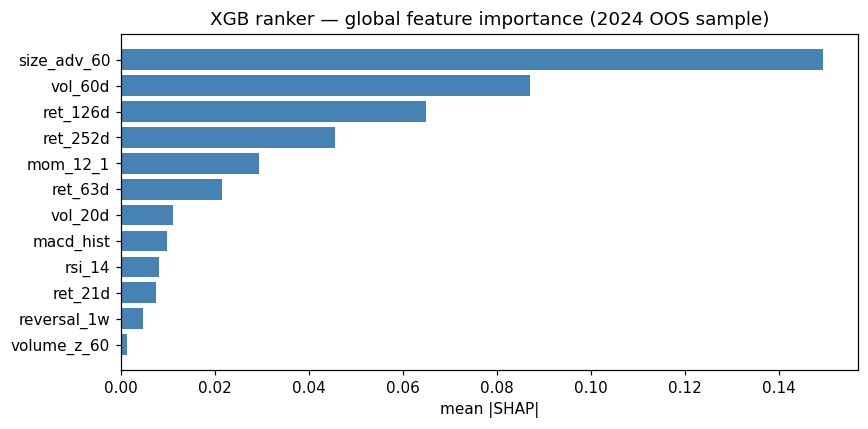

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance["feature"][::-1], importance["mean_abs_shap"][::-1], color="steelblue")
ax.set_xlabel("mean |SHAP|")
ax.set_title("XGB ranker — global feature importance (2024 OOS sample)")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_shap_importance.png", dpi=130, bbox_inches="tight")
plt.show()

## 4. Beeswarm — direction and dispersion per feature

Each dot is one (stock, date); horizontal position is that row's SHAP
contribution, colour is the feature's value. Red-on-right / blue-on-left is
a positive monotone relationship; a mixed pattern means the feature's effect
depends on interactions.

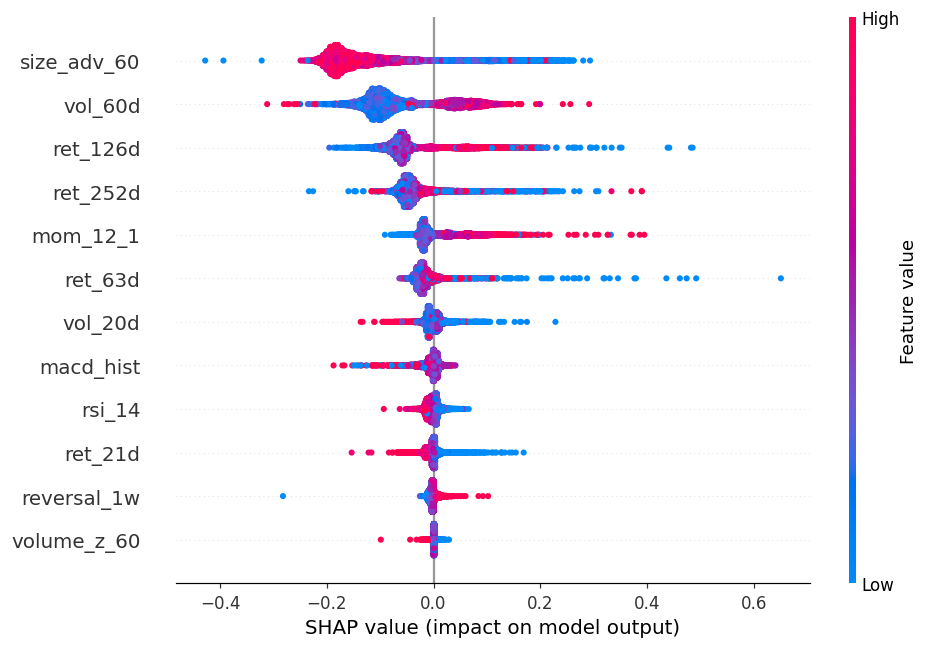

In [8]:
shap.summary_plot(
    shap_vals, X_sample, feature_names=FEATURES,
    show=False, max_display=len(FEATURES),
)
plt.gcf().set_size_inches(9, 6)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_shap_beeswarm.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Dependence plots — top three features

Dependence plot = SHAP value on y-axis vs the feature's raw value on x-axis.
Reveals whether the relationship is monotone (linear models would capture it)
or non-linear (only trees capture it).

top-3: ['size_adv_60', 'vol_60d', 'ret_126d']


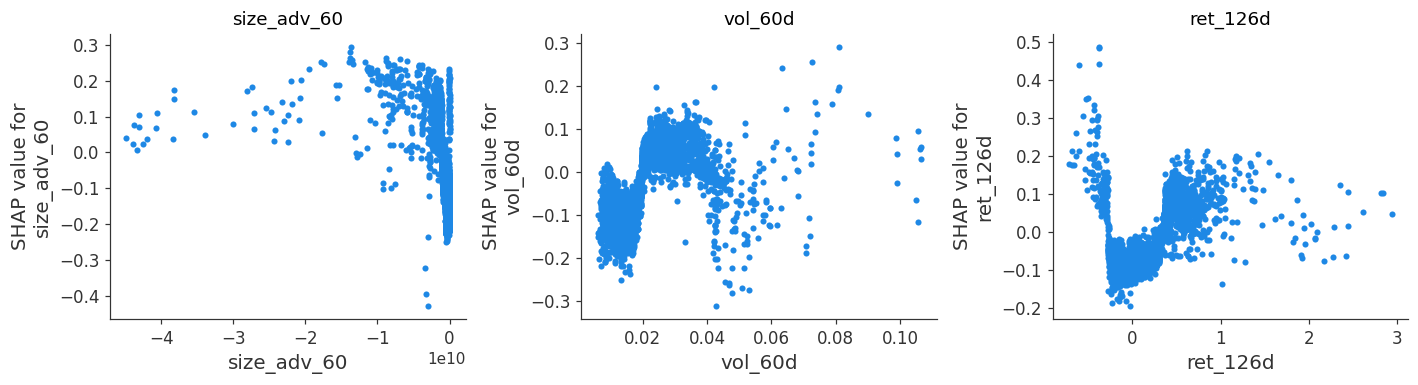

In [9]:
top3 = importance["feature"].head(3).tolist()
print("top-3:", top3)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, feat in zip(axes, top3):
    shap.dependence_plot(
        feat, shap_vals, X_sample, feature_names=FEATURES,
        interaction_index=None, ax=ax, show=False,
    )
    ax.set_title(feat)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_shap_dependence_top3.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Does the model beat `naive_ew` because of the 3 handmade features — or the rest?

Naive-EW uses `size_adv_60`, `vol_60d`, `reversal_1w`. If SHAP importance
concentrates almost entirely on those three, the XGB ranker is essentially a
noisy version of the handmade baseline and the 0.09 IC-IR gap is either
non-linearity within those three features or random-fold luck.

If importance spreads more evenly across the 12 features, the gap comes from
the model exploiting features the linear baseline could not use (the
wrong-sign momentum group).

In [10]:
ew_features = {"size_adv_60", "vol_60d", "reversal_1w"}
importance["in_naive_ew"] = importance["feature"].isin(ew_features)

share = (
    importance.groupby("in_naive_ew")["mean_abs_shap"].sum()
    / importance["mean_abs_shap"].sum()
)
print(share.rename(lambda x: "naive_ew features" if x else "other 9 features").round(3))

in_naive_ew
other 9 features     0.452
naive_ew features    0.548
Name: mean_abs_shap, dtype: float32


## 7. Takeaways

### 7.1 Top-3 features: size, vol, medium-horizon return.
Mean |SHAP| ranking puts **`size_adv_60` (0.149)**, **`vol_60d` (0.087)**,
**`ret_126d` (0.065)** on top. Size is the single largest contributor —
more than double vol_60d — consistent with the liquidity / small-cap
premium being the strongest single-feature IC in 01_feature_eda. Vol_60d
second aligns with the "low-vol anomaly reversed" finding. **ret_126d is
the surprise**: its standalone IC-IR in the EDA was −0.03 (essentially
noise), but the model ranks it third on global importance. That is a
textbook tree-model signature — the feature is useless linearly but
informative *conditional* on size and vol buckets.

### 7.2 Roughly half the model's importance lives outside `naive_ew`'s three features.
| Group | share of Σ mean |SHAP| |
|---|---|
| `naive_ew` features (size_adv_60, vol_60d, reversal_1w) | 54.8% |
| Other 9 features | 45.2% |

This is the clearest possible answer to "where does XGB's 0.09 IC-IR edge
over `naive_ew` come from?" Roughly half of what the tree model does is
re-derive the handmade signal; the other half exploits features — most
prominently the medium-horizon returns (`ret_126d`, `ret_252d`,
`mom_12_1`) — that a linear model could not use because their individual
ICs are near zero or wrong-signed. Worth noting `reversal_1w`, one of the
three handmade features, is actually ranked 11th — so the "naive_ew"
contribution is effectively coming from size + vol, and reversal_1w is
mostly redundant with `ret_21d` and `rsi_14` inside the tree splits.

### 7.3 `volume_z_60` is essentially unused.
Last place with mean |SHAP| of 0.001 — two orders of magnitude below
size_adv_60. That matches its IC-IR of 0.05 in the EDA (weakest of the
positive-IC features), and justifies dropping it from the linear baseline
on the next pass without any model-quality cost.

### 7.4 Interaction structure shows up in the dependence plots.
For `size_adv_60` the dependence is expectedly monotone — large negative
ADV (i.e. smaller names) gets positive SHAP, big-ADV names get negative
SHAP, a clean size tilt. For `vol_60d` the direction is positive
(high-vol → positive SHAP) but with noticeably more spread, indicating
the effect is conditional on other features rather than a clean linear
tilt. For `ret_126d` the dependence is the non-linear case that makes
this notebook worth running — the SHAP signs at the two tails carry
opposite directions depending on other features, which is precisely why
its marginal IC was ≈ 0 but its tree importance is high.

### 7.5 What this means for the README framing.
The honest pitch is: **"XGB's out-performance over `naive_ew` is half a
size-and-vol tilt the baseline already captures, and half the model
learning that medium-horizon return features — which look dead in
isolation — carry signal conditional on size and volatility buckets."**
That framing avoids overclaiming sophistication the model does not have
(there is no exotic pattern) while giving a concrete mechanistic reason
the tree model beats the linear one.

### 7.6 Deferred (see SDD).
Per-fold SHAP drift over 2020/2021/2022/2023/2024 would tell us whether
the feature mix shifts before the 2022 IC blow-up. Scoped out of the MVP
notebook; a follow-up when time allows.